<a href="https://colab.research.google.com/github/sayak395/Jaynes-Cummings-model/blob/main/Parameterisation_of_JC_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qutip

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from qutip import (basis, destroy, mesolve, qeye, tensor, create, sigmaz, sigmam, sigmap, fock, Qobj, fidelity, Options)
from scipy.signal import find_peaks

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/30.1 MB 43.2 MB/s eta 0:00:00


In [15]:
# Hilbert space dimension for the cavity
n_cavity = 10
sigma_z_np = np.array([[1 , 0],
                   [0, -1]])
sigma_z_alt = Qobj(sigma_z_np)
sigma_plus_np = np.array([[0, 1],
                   [0, 0]])
sigma_plus_alt = Qobj(sigma_plus_np)
sigma_minus_np = np.transpose(sigma_plus_np)
sigma_minus_alt = Qobj(sigma_minus_np)

In [11]:
###########################
# Define the Operators
###########################

sigma_minus = tensor(qeye(n_cavity), sigma_minus_alt) # atomic lowering operator
sigma_plus =  tensor(qeye(n_cavity), sigma_plus_alt)  # atomic raising operator
sigma_z = tensor(qeye(n_cavity), sigma_z_alt)     # atomic z operator
a = tensor(destroy(n_cavity), qeye(2))   # cavity annihilation operator
spin_down = fock(2, 1)
spin_up = fock(2, 0)

In [31]:
wc = wa = 1.0  # Example values
w0 = wc # resonance driving
delta_c = (wc - w0)/wc
delta_a = (wa - w0)/wc
g = 0.05 * wc

In [13]:
psi = tensor(fock(n_cavity, 0), spin_down)
psi_den = psi * psi.dag()
target_state = tensor(fock(n_cavity, 1), spin_down)
target_den = target_state * target_state.dag()

In [17]:
from scipy.interpolate import CubicSpline
!pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real
from skopt.plots import plot_convergence
from skopt.utils import use_named_args

from skopt.plots import plot_convergence, plot_objective, plot_evaluations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.6 MB/s eta 0:00:00


We are now parameterising the system with one point in the middle and optimising. Later on we can implement the optimal x time for the new point too.

In [25]:
def f_t(t, args):

  frequency = args['frequencies']
  envelope_func = args['spline']

  return envelope_func(t) * np.cos(frequency * t)




In [ ]:
def objective_general(frequency, envelope_y_value, envelope_x_value, sim_time):

    if (envelope_x_value >= sim_time) or (envelope_x_value <= 0):
        return float('0')  # Penalize if envelope_x_value is out of bounds

    envelope_values = [0, envelope_y_value, 0]
    control_times = [0, envelope_x_value, sim_time]

    # Create a cubic spline for the envelope function
    spline = CubicSpline(control_times, envelope_values, extrapolate=False)

    args = {
        'frequencies': frequency,
        'spline': spline,
        'sim_time': sim_time
    }

    tau = wc * sim_time  # Time array for simulation

    H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g/wc) * (sigma_plus * a + sigma_minus * a.dag())
    H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t: f_t(t, args)]

    H = [H_static, H_drive]

    result = mesolve(H, psi_den, [0, tau], c_ops=[], e_ops=[], options={'nsteps': 1e9, 'atol': 1e-7, 'rtol': 1e-7})
    final_rho = result.states[-1]
    fid = fidelity(final_rho, target_den)
    return -fid  # Minimize negative fidelity

def objective(x):
    return objective_general(x[0], x[1], x[2], x[3])


# Define the parameter space for Bayesian Optimisation
space = [Real(0.0, 10.0, name='frequency'),
         Real(0, g, name='envelope_y_value'),
         Real(0, 1000, name='envelope_x_value'),
          Real(0, 1000, name='sim_time')]
# Perform Bayesian Optimisation
res = gp_minimize(objective, space, n_calls=100, random_state=42, verbose=True, acq_func='EI')

# Print the best parameters found
print(f"Optimal frequency: {res.x[0]}, Optimal envelope y-value: {res.x[1]}, Optimal envelope x-value: {res.x[2]}, Optimal simulation time: {res.x[-1]}")

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.0009
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 0.0008
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 3.8133
Function value obtained: -0.0000
Current minimum: -0.0000
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.0007
Function value obtained: 0.0000
Current minimum: -0.0000
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 5.9939
Function value obtained: -0.0005
Current minimum: -0.0005
Iteration No: 6 started. Evalu

In [ ]:
# Assuming 'res' holds the results from Bayesian optimization and contains optimal values
optimal_frequency = res.x[0]
optimal_envelope_value = res.x[1]
optimal_envelope_x_value = res.x[2]
optimal_sim_time = res.x[-1]

# Define the envelope function using optimal parameters
envelope_values = [0, optimal_envelope_value, 0]
control_times = [0, optimal_envelope_x_value, optimal_sim_time]
spline = CubicSpline(control_times, envelope_values, extrapolate=False)

# Time array for the simulation, using the optimal simulation time
tau = np.linspace(0, optimal_sim_time, 1000)

envelope = spline(tau)
cosine_wave = np.cos(optimal_frequency * tau)
modulated_wave = envelope * cosine_wave

# Plotting the envelope and the modulated signal
plt.figure(figsize=(10, 6))

plt.plot(tau, modulated_wave, label='$g(t) \\cdot \\cos(\\omega t)$', linewidth=2, color ='royalblue')
plt.plot(tau, envelope, label='Envelope $g(t)$', linestyle='--',color='red', linewidth=2)
plt.scatter(control_times[1], envelope_values[1], marker = 'x', color = 'black', label = 'Envelope Parameterisation Point')
plt.title('Envelope and Modulated Signal Over Time')
plt.xlabel('Time (arb. units)')
plt.ylabel('Driving Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
plot_convergence(res)
plt.show()

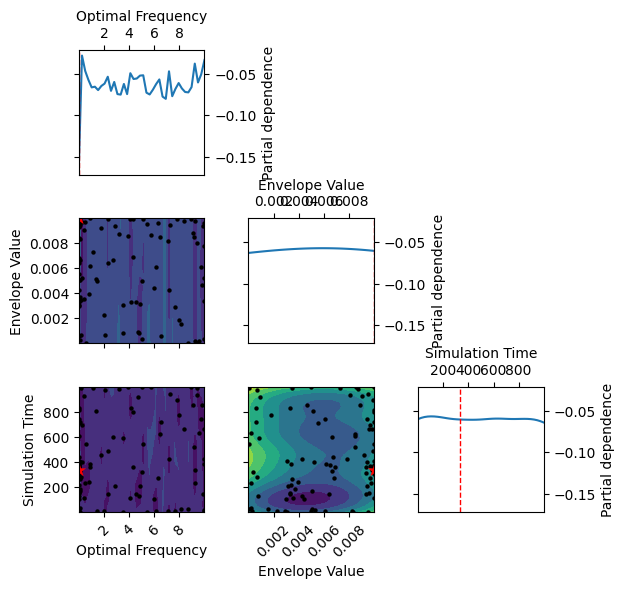

In [29]:
fig = plot_objective(res, dimensions=['Optimal Frequency', 'Envelope Value', 'Simulation Time'])
plt.show()

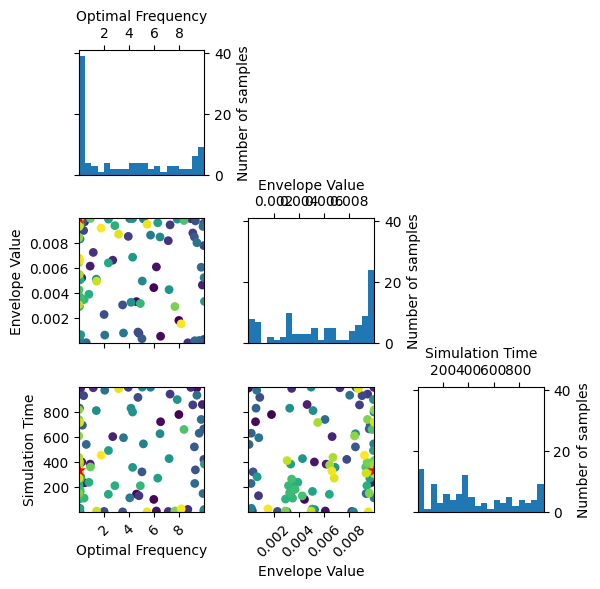

In [30]:
fig = plot_evaluations(res, dimensions=['Optimal Frequency', 'Envelope Value', 'Simulation Time'])
plt.show()